# Importing Librirys & Visualizing dataset

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

# Load dataset
df_feat = pd.read_csv('D:/download/archive/smartphone_battery_features.csv')
df_targ = pd.read_csv('D:/download/archive/smartphone_battery_targets.csv')
df = pd.merge(df_feat, df_targ, on='Device_ID')

# Display basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nData Types:\n", df.dtypes)



Dataset Shape: (5000, 17)

Data Types:
 Device_ID                            object
device_age_months                     int64
battery_capacity_mah                  int64
avg_screen_on_hours_per_day         float64
avg_charging_cycles_per_week        float64
avg_battery_temp_celsius            float64
fast_charging_usage_percent         float64
overnight_charging_freq_per_week      int64
gaming_hours_per_week               float64
video_streaming_hours_per_week      float64
background_app_usage_level           object
signal_strength_avg                  object
charging_habit_score                  int64
usage_intensity_score               float64
thermal_stress_index                float64
current_battery_health_percent      float64
recommended_action                   object
dtype: object


# Task 1

In [20]:
# Check the statistical spread of signal strength
print(df['signal_strength_avg'].describe())

count     5000
unique       3
top       Good
freq      3025
Name: signal_strength_avg, dtype: object


In [21]:
# Strip potential symbols and convert to numeric
df['signal_strength_avg'] = df['signal_strength_avg'].replace(r'[^\d.-]', '', regex=True)
df['signal_strength_avg'] = pd.to_numeric(df['signal_strength_avg'])

print("Updated Data Types:\n", df.dtypes)

Updated Data Types:
 Device_ID                            object
device_age_months                     int64
battery_capacity_mah                  int64
avg_screen_on_hours_per_day         float64
avg_charging_cycles_per_week        float64
avg_battery_temp_celsius            float64
fast_charging_usage_percent         float64
overnight_charging_freq_per_week      int64
gaming_hours_per_week               float64
video_streaming_hours_per_week      float64
background_app_usage_level           object
signal_strength_avg                 float64
charging_habit_score                  int64
usage_intensity_score               float64
thermal_stress_index                float64
current_battery_health_percent      float64
recommended_action                   object
dtype: object


# Task 2

In [22]:
# Handle missing values (if any)
df.isna().sum()

Device_ID                              0
device_age_months                      0
battery_capacity_mah                   0
avg_screen_on_hours_per_day            0
avg_charging_cycles_per_week           0
avg_battery_temp_celsius               0
fast_charging_usage_percent            0
overnight_charging_freq_per_week       0
gaming_hours_per_week                  0
video_streaming_hours_per_week         0
background_app_usage_level             0
signal_strength_avg                 5000
charging_habit_score                   0
usage_intensity_score                  0
thermal_stress_index                   0
current_battery_health_percent         0
recommended_action                     0
dtype: int64

In [23]:
# Drop the column since it contains 100% missing values
df.drop(columns=['signal_strength_avg'], inplace=True)


In [24]:
df.isna().sum()

Device_ID                           0
device_age_months                   0
battery_capacity_mah                0
avg_screen_on_hours_per_day         0
avg_charging_cycles_per_week        0
avg_battery_temp_celsius            0
fast_charging_usage_percent         0
overnight_charging_freq_per_week    0
gaming_hours_per_week               0
video_streaming_hours_per_week      0
background_app_usage_level          0
charging_habit_score                0
usage_intensity_score               0
thermal_stress_index                0
current_battery_health_percent      0
recommended_action                  0
dtype: int64

In [25]:
from sklearn.preprocessing import MinMaxScaler

# List the features to scale (excluding IDs or non-numeric categories)
features_to_scale = ['battery_capacity_mah', 'avg_battery_temp_celsius', 'device_age_months', 'avg_charging_cycles_per_week']

# 1. Initialize the scaler
scaler_minmax = MinMaxScaler()

# 2. Copy the dataframe cleaned from previous tasks
df_minmax = df.copy()

# 3. Fit and transform the data
df_minmax[features_to_scale] = scaler_minmax.fit_transform(df_minmax[features_to_scale])

print("Min-Max Scaled Features:\n", df_minmax[features_to_scale].head())

Min-Max Scaled Features:
    battery_capacity_mah  avg_battery_temp_celsius  device_age_months  \
0                  0.75                  0.673469           0.791667   
1                  0.00                  0.704082           0.583333   
2                  0.00                  0.397959           0.291667   
3                  0.00                  0.571429           0.875000   
4                  0.00                  0.872449           0.145833   

   avg_charging_cycles_per_week  
0                      0.538462  
1                      0.467949  
2                      0.525641  
3                      0.339744  
4                      0.551282  


In [26]:
from sklearn.preprocessing import StandardScaler

# 1. Initialize the scaler
scaler_std = StandardScaler()

# 2. Copy the dataframe
df_zscore = df.copy()

# 3. Fit and transform the data
df_zscore[features_to_scale] = scaler_std.fit_transform(df_zscore[features_to_scale])

print("Z-Score Standardized Features:\n", df_zscore[features_to_scale].head())

Z-Score Standardized Features:
    battery_capacity_mah  avg_battery_temp_celsius  device_age_months  \
0              0.490344                  1.136922           0.973898   
1             -1.523113                  1.372745           0.266514   
2             -1.523113                 -0.985491          -0.723824   
3             -1.523113                  0.350843           1.256852   
4             -1.523113                  2.669775          -1.218993   

   avg_charging_cycles_per_week  
0                      1.011049  
1                      0.648519  
2                      0.945134  
3                     -0.010625  
4                      1.076963  


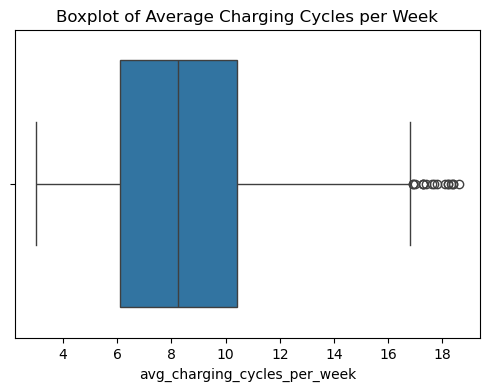

In [27]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['avg_charging_cycles_per_week'])
plt.title("Boxplot of Average Charging Cycles per Week")
plt.show()

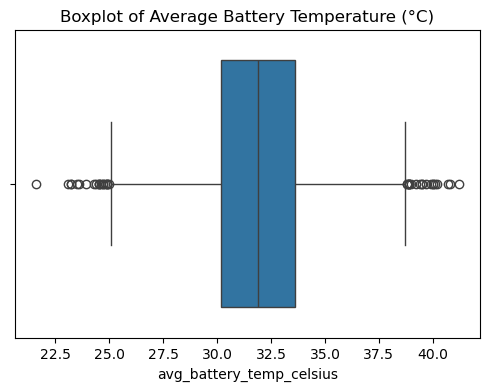

In [28]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['avg_battery_temp_celsius'])
plt.title("Boxplot of Average Battery Temperature (°C)")
plt.show()

# Task 3

In [29]:
Q1 = df['avg_battery_temp_celsius'].quantile(0.25)
Q3 = df['avg_battery_temp_celsius'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['avg_battery_temp_celsius'] < lower) | (df['avg_battery_temp_celsius'] > upper)]
outliers.head(15)

,Device_ID,device_age_months,battery_capacity_mah,avg_screen_on_hours_per_day,avg_charging_cycles_per_week,avg_battery_temp_celsius,fast_charging_usage_percent,overnight_charging_freq_per_week,gaming_hours_per_week,video_streaming_hours_per_week,background_app_usage_level,charging_habit_score,usage_intensity_score,thermal_stress_index,current_battery_health_percent,recommended_action
81,a79dbecb-9197-43d3-8275-fe2b1492d7e9,39,4000,1.8,3.0,24.7,59.9,7,0.8,8.6,Low,4,10.0,1.16,62.2,Replace Battery
103,8d7df481-2150-4ba1-902e-12c23abeaf88,23,5000,8.7,14.5,39.7,70.1,6,4.9,4.9,Medium,5,10.0,4.96,40.0,Change Phone
247,4c1542d5-6e20-41f6-aa11-67c77e7a412f,19,4000,7.0,8.3,38.9,64.5,0,14.2,15.5,Medium,8,10.0,5.47,58.8,Replace Battery
671,dc40d2c6-17cc-4962-b593-ca4e67f1c441,18,4000,5.4,8.6,38.8,39.1,5,9.6,17.7,Medium,6,10.0,5.10,59.5,Replace Battery
746,f4e77d7b-4033-4d33-bbab-b13d21846d72,45,4500,1.0,3.0,24.4,44.1,0,3.1,6.9,Low,8,10.0,1.26,71.5,Replace Battery
790,e1a9360f-002b-4e2e-8141-4e3a0740799c,9,5000,4.8,7.6,24.9,70.9,0,4.4,6.1,Medium,7,10.0,1.47,84.0,Keep Using
791,b61f23e9-1443-4169-8199-0fac5b43df9f,9,4500,6.4,11.3,40.1,74.4,2,5.1,5.3,High,6,10.0,5.07,65.0,Replace Battery
801,d5b64acd-e06b-4230-8522-26c22a36a62f,3,3000,4.2,6.8,24.8,59.2,4,3.6,14.6,High,7,10.0,1.40,95.7,Keep Using
1203,42157d7d-04b2-4d33-9b20-18733e2737aa,48,4500,9.6,16.2,39.0,72.8,6,4.8,11.5,Low,5,10.0,4.80,10.0,Change Phone
1241,b709b280-69ed-4f7a-8735-d2516231730a,33,3000,5.4,8.9,40.0,43.7,7,2.8,13.4,High,5,10.0,4.86,33.6,Change Phone


In [30]:
Q1 = df['avg_charging_cycles_per_week'].quantile(0.25)
Q3 = df['avg_charging_cycles_per_week'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['avg_charging_cycles_per_week'] < lower) | (df['avg_charging_cycles_per_week'] > upper)]
outliers.head(15)

,Device_ID,device_age_months,battery_capacity_mah,avg_screen_on_hours_per_day,avg_charging_cycles_per_week,avg_battery_temp_celsius,fast_charging_usage_percent,overnight_charging_freq_per_week,gaming_hours_per_week,video_streaming_hours_per_week,background_app_usage_level,charging_habit_score,usage_intensity_score,thermal_stress_index,current_battery_health_percent,recommended_action
141,4db41c9c-1e9f-4b5a-bed4-152b812cc161,38,5000,11.3,18.3,35.8,74.2,0,1.7,16.4,High,7,10.0,3.81,17.6,Change Phone
352,d591cae6-d967-4213-8fbb-859b64c7379f,16,4500,11.8,17.7,38.1,37.3,6,3.8,17.7,High,5,10.0,4.51,44.4,Change Phone
483,28c98055-3f62-4b2e-8c0d-7419a7a5f66d,27,4500,10.9,17.0,36.4,33.5,7,3.8,20.9,Medium,4,10.0,4.10,30.0,Change Phone
507,c5213852-1b1d-46e2-878f-0f2d3c8519aa,9,4500,12.0,18.1,34.5,83.4,7,9.6,11.3,Medium,4,10.0,4.10,65.1,Replace Battery
586,d68d6a03-a9a5-4d93-ba19-232d9180ade0,34,5000,10.7,16.9,34.3,86.1,3,1.8,16.5,Medium,6,10.0,3.47,18.7,Change Phone
1235,df4c8899-45c0-4f55-9167-ad868b9c4d83,10,5000,11.0,17.8,34.9,34.0,0,0.1,9.9,High,8,10.0,3.49,64.3,Replace Battery
1872,23d93d26-478c-4a3a-ad04-a31ec80a0cd6,26,4500,11.3,18.4,37.0,63.0,1,5.8,8.7,High,7,10.0,4.40,31.0,Change Phone
2499,ffcd07d8-3af0-4415-ba85-9b69b32d7533,39,5000,10.6,17.6,33.4,76.4,2,5.3,11.0,Medium,7,10.0,3.52,13.1,Change Phone
2777,fcbb5b93-f6fd-4924-b011-86aec967b257,8,4000,10.1,16.9,34.2,63.2,1,2.7,6.0,Low,7,10.0,3.50,72.7,Replace Battery
2816,24fdacea-cc7d-4baf-a2c5-ecfc14994eff,20,4000,11.7,17.3,39.2,45.2,1,8.2,10.8,Low,8,10.0,5.10,45.5,Change Phone


# Task 4

In [31]:
from sklearn.preprocessing import MinMaxScaler

# List the features to scale (excluding IDs or non-numeric categories)
features_to_scale = ['battery_capacity_mah', 'avg_battery_temp_celsius', 'device_age_months', 'avg_charging_cycles_per_week']

# 1. Initialize the scaler
scaler_minmax = MinMaxScaler()

# 2. Copy the dataframe cleaned from previous tasks
df_minmax = df.copy()

# 3. Fit and transform the data
df_minmax[features_to_scale] = scaler_minmax.fit_transform(df_minmax[features_to_scale])

print("Min-Max Scaled Features:\n", df_minmax[features_to_scale].head())

Min-Max Scaled Features:
    battery_capacity_mah  avg_battery_temp_celsius  device_age_months  \
0                  0.75                  0.673469           0.791667   
1                  0.00                  0.704082           0.583333   
2                  0.00                  0.397959           0.291667   
3                  0.00                  0.571429           0.875000   
4                  0.00                  0.872449           0.145833   

   avg_charging_cycles_per_week  
0                      0.538462  
1                      0.467949  
2                      0.525641  
3                      0.339744  
4                      0.551282  


In [32]:
from sklearn.preprocessing import StandardScaler

# 1. Initialize the scaler
scaler_std = StandardScaler()

# 2. Copy the dataframe
df_zscore = df.copy()

# 3. Fit and transform the data
df_zscore[features_to_scale] = scaler_std.fit_transform(df_zscore[features_to_scale])

print("Z-Score Standardized Features:\n", df_zscore[features_to_scale].head())

Z-Score Standardized Features:
    battery_capacity_mah  avg_battery_temp_celsius  device_age_months  \
0              0.490344                  1.136922           0.973898   
1             -1.523113                  1.372745           0.266514   
2             -1.523113                 -0.985491          -0.723824   
3             -1.523113                  0.350843           1.256852   
4             -1.523113                  2.669775          -1.218993   

   avg_charging_cycles_per_week  
0                      1.011049  
1                      0.648519  
2                      0.945134  
3                     -0.010625  
4                      1.076963  


# Task 5

In [33]:
from sklearn.decomposition import PCA

# Use the standardized (Z-score) data for PCA
X = df_zscore[features_to_scale]

# 1. Initialize PCA to find 2 main components
pca = PCA(n_components=2)

# 2. Fit and transform the features
principal_components = pca.fit_transform(X)

# 3. Print the explained variance ratio
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.34234021 0.25228866]


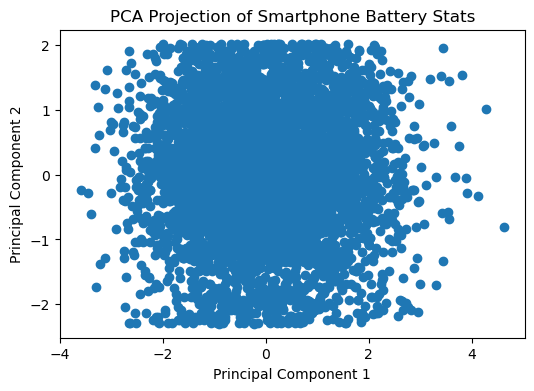

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1])
plt.title("PCA Projection of Smartphone Battery Stats")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()